In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"C:\Users\PC\OneDrive\Desktop\Retail_Project\data\train.csv")

In [3]:
type(data)

pandas.core.frame.DataFrame

In [4]:
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [5]:
data = data.dropna()

In [6]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [7]:
data.duplicated().sum()

0

In [8]:
data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [9]:
data["Order Date"] = pd.to_datetime(data["Order Date"], dayfirst=True)
data["Ship date"] = pd.to_datetime(data["Ship Date"], dayfirst=True)

In [10]:
data.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Ship date        datetime64[ns]
dtype: object

# Product Analysis

## Business Question
Which products generate the highest sales?

In [11]:
top_products = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

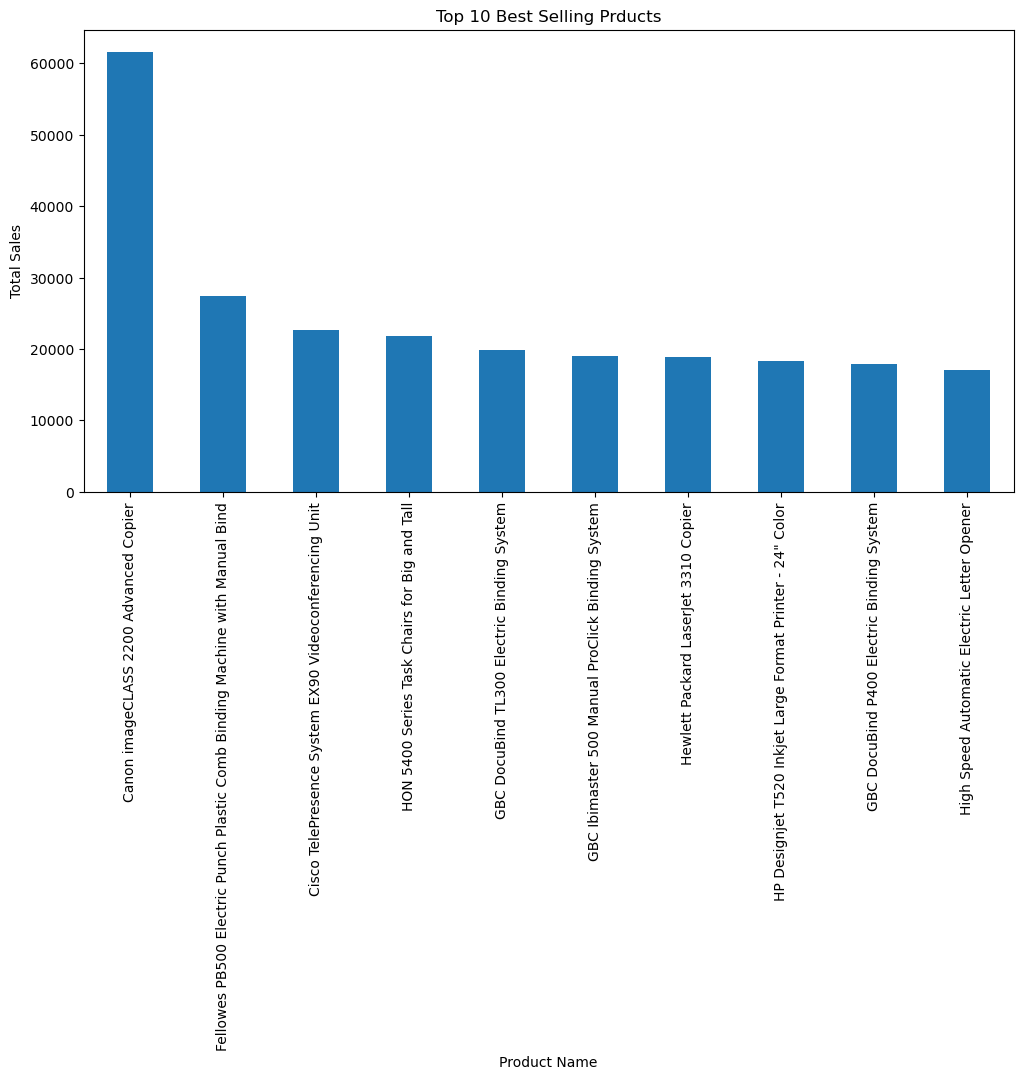

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
top_products.plot(kind="bar")
plt.title("Top 10 Best Selling Prducts")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

## Business Insight

- The graph shows the top 10 products with the highest sales.
- These products contribute the most to company revenue.
- The company should ensure these products are always available in stock.
- These products can be highlighted in promotional campaigns.

# Customer Analysis

## Business Question
Which customers contribute the highest sales?

In [13]:
top_customers = data.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

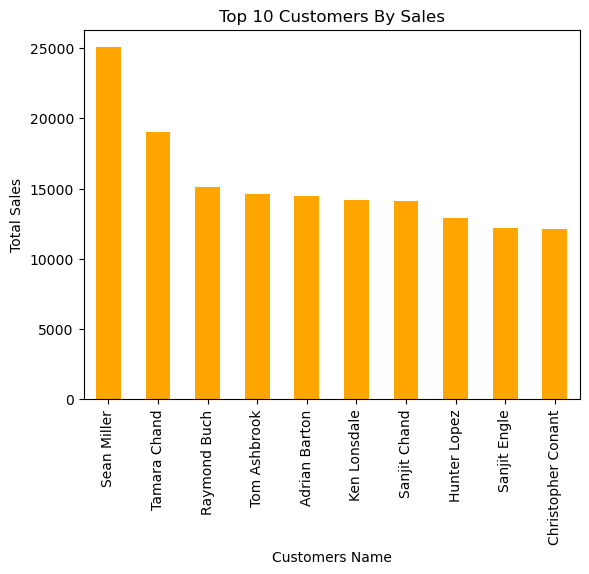

In [14]:
plt.figure(figure=(12,6))
top_customers.plot(kind="bar", color="orange")
plt.title("Top 10 Customers By Sales")
plt.xlabel("Customers Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

## Business Insight

- These customers contribute the highest sales.
- The company should focus on retaining these valuable customers.
- Loyalty programs and exclusive offers can increase repeat purchases.

# Category Analysis

## Business Question
Which product category generates the highest sales?

In [15]:
category_sales = data.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

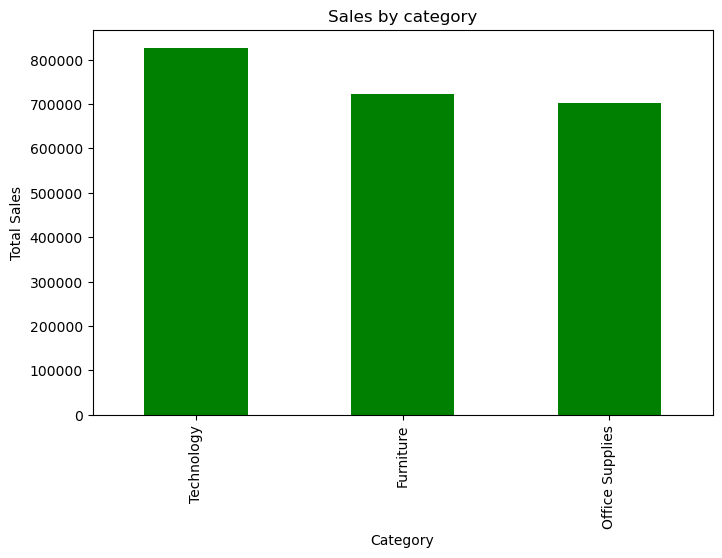

In [16]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar", color="green")
plt.title("Sales by category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

## Business Insight

- This analysis shows which product category generates the highest sales.
- The company should focus more on high-performing categories.
- Low-performing categories should be reviewed for improvement.

# Executive Summary

This Retail Business Intelligence project analyzes retail sales data to identify key business trends.

Key Findings:
- Identified the top-selling products.
- Identified the highest-value customers.
- Compared sales across product categories.
- Generated business insights to support decision-making.

# Business Recommendations

1. Increase inventory for top-selling products.
2. Reward high-value customers through loyalty programs.
3. Focus marketing campaigns on the best-performing categories.
4. Improve sales strategies for low-performing categories.
5. Use data-driven decisions for future business planning.

# Retail Sales Dashboard
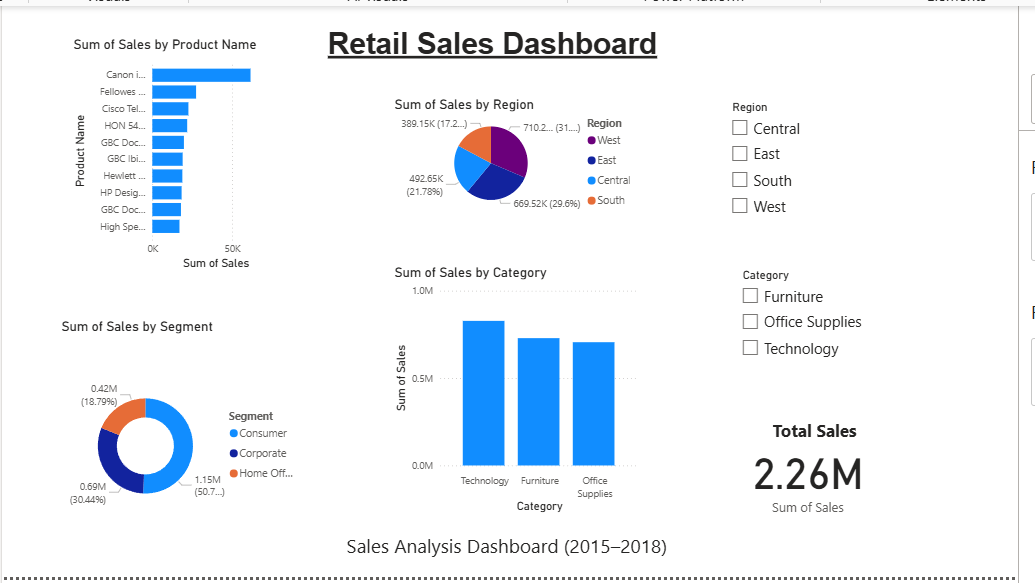

In [17]:
print (data.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Ship date'],
      dtype='object')


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [19]:
df_ml = data[['Category','Region','Sales']].copy()

le1 = LabelEncoder()
le2 = LabelEncoder()

df_ml['Category'] = le1.fit_transform(df_ml['Category'])
df_ml['Region'] = le2.fit_transform(df_ml['Region'])

In [20]:
X = df_ml[['Category','Region']]
y = df_ml['Sales']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

In [24]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 286.67267576521056
R2 Score: 0.0016145890501890747


# SQL Queries Used

## Total Sales
SELECT SUM(Sales) FROM RetailSales;

## Sales by Category
SELECT Category, SUM(Sales)
FROM RetailSales
GROUP BY Category;

## Sales by Region
SELECT Region, SUM(Sales)
FROM RetailSales
GROUP BY Region;

## Top 10 Products
SELECT Product_Name, SUM(Sales) AS TotalSales
FROM RetailSales
GROUP BY Product_Name
ORDER BY TotalSales DESC
LIMIT 10;

# Conclusion

This Retail Sales Analysis project was developed using Python, Pandas, SQL concepts, Power BI and Scikit-learn.

Key Findings:
- Technology category generated the highest sales.
- West region contributed the maximum sales.
- Consumer segment had the highest sales.
- Top 10 products were identified using sales analysis.
- A Linear Regression model was created using Scikit-learn to demonstrate machine learning.

The dashboard provides useful business insights for decision-making.

# Future Scope

- Improve sales prediction using more features.
- Add Profit and Quantity analysis.
- Deploy dashboard on the web.
- Connect dashboard with live database.
- Build interactive reports for business users.

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL
- Power BI
- Scikit-learn
- Jupyter Notebook

# Project Workflow

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Business Insights
5. SQL Analysis
6. Machine Learning (Scikit-learn)
7. Power BI Dashboard
8. Conclusion